# 🌍 Environmental Monitoring Agent

A fully agentic ADK-based ecosystem monitoring system using Google Earth Engine.

## 🛠️ Step 1: Setup and Authentication

In [ ]:
!pip install google-adk google-generativeai earthengine-api geemap -q

import os
import ee
import datetime
import pandas as pd
import geemap
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from getpass import getpass

# Authenticate GEE before initializing
ee.Authenticate()
ee.Initialize(project='ee-tmyothu')  # Replace with your GEE project ID

# Use GOOGLE_API_KEY env var — required by ADK
api_key = getpass('Enter your Google API Key: ')
os.environ['GOOGLE_API_KEY'] = api_key

Enter your Google API Key: ··········


## 🛰️ Step 2: Define the Earth Engine Tool

In [ ]:
# Tool returns a plain string so the LLM can read it.
# Interactive map and chart are displayed as side-effects.
def analyze_ecosystem_monitoring_tool(lat: float, lon: float, start_year: int, end_year: int) -> str:
    """
    Analyzes ecosystem health for a given GPS coordinate over a range of years.
    Calculates NDVI, EVI, LST (land) and SST (ocean) using Landsat 8 C2 and MODIS datasets.
    Saves a time-series chart as 'ecosystem_analysis.png' and displays an interactive map.
    Returns a structured markdown report string summarizing the findings.

    Args:
        lat: Latitude of the location to analyze.
        lon: Longitude of the location to analyze.
        start_year: First year of the analysis period (e.g. 2015).
        end_year: Last year of the analysis period (e.g. 2026).

    Returns:
        A markdown-formatted report string with ecosystem metrics and insights.
    """
    roi = ee.Geometry.Point([lon, lat]).buffer(5000).bounds()
    years = list(range(start_year, end_year + 1))
    results = {"NDVI": [], "EVI": [], "LST": [], "SST": []}

    # Interactive map (side-effect — not returned to agent)
    Map = geemap.Map(center=[lat, lon], zoom=12)

    for year in years:
        l8_coll = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                     .filterBounds(roi)
                     .filter(ee.Filter.calendarRange(year, year, 'year'))
                     .median())

        modis_sst = (ee.ImageCollection("NASA/OCEANDATA/MODIS-Aqua/L3SMI")
                       .filterBounds(roi)
                       .filterDate(f'{year}-01-01', f'{year}-12-31')
                       .select('sst')
                       .median())

        has_land = l8_coll.bandNames().size().getInfo() > 0
        has_sea  = modis_sst.bandNames().size().getInfo() > 0

        # --- Land (Landsat 8 C2) ---
        if has_land:
            optical = l8_coll.select('SR_B.').multiply(0.0000275).add(-0.2)
            thermal = (l8_coll.select('ST_B10')
                              .multiply(0.00341802).add(149.0).subtract(273.15))

            ndvi = optical.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
            evi  = optical.expression(
                '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
                {'NIR': optical.select('SR_B5'),
                 'RED': optical.select('SR_B4'),
                 'BLUE': optical.select('SR_B2')}
            ).rename('EVI')

            results["NDVI"].append(ndvi.reduceRegion(ee.Reducer.mean(), roi, 30).get('NDVI').getInfo())
            results["EVI"].append(evi.reduceRegion(ee.Reducer.mean(), roi, 30).get('EVI').getInfo())
            results["LST"].append(thermal.reduceRegion(ee.Reducer.mean(), roi, 30).get('ST_B10').getInfo())

            if year == end_year:
                Map.addLayer(ndvi,    {'min': 0,  'max': 0.8, 'palette': ['white', 'green']},           'NDVI (Latest)')
                Map.addLayer(evi,     {'min': 0,  'max': 0.8, 'palette': ['#F8FAFC', '#3B82F6']},        'EVI (Latest)')
                Map.addLayer(thermal, {'min': 15, 'max': 40,  'palette': ['blue', 'yellow', 'red']},     'LST (Latest)')
        else:
            for k in ['NDVI', 'EVI', 'LST']:
                results[k].append(None)

        # --- Sea (MODIS SST) ---
        if has_sea:
            sst_val = modis_sst.reduceRegion(ee.Reducer.mean(), roi, 4000).get('sst').getInfo()
            results["SST"].append(sst_val)
            if year == end_year:
                Map.addLayer(modis_sst, {'min': 10, 'max': 35, 'palette': ['blue', 'cyan', 'yellow']}, 'SST (Latest)')
        else:
            results["SST"].append(None)

    # Get_delta always returns a 3-tuple — original crashed with wrong unpacking
    def get_delta(data_list):
        vals = [v for v in data_list if v is not None]
        if len(vals) < 2:
            fv = vals[0] if vals else 0
            return fv, fv, 0.0   # (start, end, pct_change)
        change = vals[-1] - vals[0]
        pct = (change / vals[0] * 100) if vals[0] != 0 else 0
        return vals[0], vals[-1], pct

    n_start, n_end, n_pct = get_delta(results["NDVI"])
    e_start, e_end, e_pct = get_delta(results["EVI"])
    l_start, l_end, _     = get_delta(results["LST"])

    status = "STABLE"
    if e_pct < -10:  status = "DEGRADED"
    elif e_pct > 5:  status = "RECOVERING"

    # --- Chart (side-effect — saved to disk) ---
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.patch.set_facecolor('#0f172a')
    metrics_meta = [("NDVI", "#10b981"), ("EVI", "#3b82f6"), ("LST", "#ef4444"), ("SST", "#0ea5e9")]

    for i, (m_name, color) in enumerate(metrics_meta):
        ax = axs[i // 2, i % 2]
        plot_data = [0 if v is None else v for v in results[m_name]]
        ax.plot(years, plot_data, color=color, marker='o', linewidth=3, markersize=8)
        ax.set_title(f"{m_name} Time-Series", color='white', fontsize=14, fontweight='bold')
        ax.set_facecolor('#f5f7fa')
        ax.tick_params(colors='#94a3b8')
        ax.grid(color='#334155', linestyle='--', alpha=0.5)
        for spine in ax.spines.values():
            spine.set_edgecolor('#475569')

    plt.tight_layout()
    img_path = 'ecosystem_analysis.png'
    plt.savefig(img_path, dpi=300)
    plt.close()

    # Display side-effects in notebook
    display(Image(img_path))
    display(Map)

    # Return plain string — ADK cannot serialize geemap.Map or PIL.Image
    report = f"""
# 🌿 Environmental Intelligence Report
**Date:** {datetime.date.today().strftime('%Y-%m-%d')} | **Location:** {lat}, {lon}

## 1. Summary Analysis
Current assessment indicates a **{status}** ecosystem for the period {start_year}-{end_year}.

| Metric | Baseline ({start_year}) | Current ({end_year}) | Trend (%) |
| :--- | :--- | :--- | :--- |
| **NDVI** | {n_start:.3f} | {n_end:.3f} | {n_pct:+.1f}% |
| **EVI**  | {e_start:.3f} | {e_end:.3f} | {e_pct:+.1f}% |
| **LST**  | {l_start:.2f}°C | {l_end:.2f}°C | {l_end - l_start:+.2f}°C |

## 2. Key Insights
- **Biomass Anomaly:** EVI shifted by **{e_pct:.1f}%**. {'Significant land-cover change detected.' if abs(e_pct) > 10 else 'Minor seasonal or cyclical variation.'}
- **Thermal Shift:** Surface temperature changed by **{l_end - l_start:.2f}°C**.
- **Sensor Note:** Landsat 8 C2 (scaled) for land; MODIS for ocean. Auto-selected based on data availability.
- **Chart & Map:** Saved to '{img_path}' and displayed above.

---
*Generated by Ecosystem Monitoring Agent*
"""
    return report

## 🤖 Step 3: Create the Monitoring Agent

In [ ]:
from google.adk.agents import Agent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai.types import Content, Part

# Tool name in instruction matches the function name exactly
agent = Agent(
    name="EcosystemMonitor",
    model="gemini-2.5-flash",
    instruction="""
    1.You are an environmental monitoring assistant.
    2.Use the 'analyze_ecosystem_monitoring_tool' to assess ecosystem health
    for user-specified locations and date ranges.
    3.Parse the returned report including introudction, Methodology, summarise key findings cleary.
    4.For backgroud information of area name in prompt, obtain available sources.
    5.Provide recommendation future conservation efforts based on the findings.
    6.If the user does not specify coordinates, ask for them.
    """,
    tools=[analyze_ecosystem_monitoring_tool]
)

# Wire up Session Service and Runner
APP_NAME    = "ecosystem_monitor"
USER_ID     = "user_01"
SESSION_ID  = "session_01"

session_service = InMemorySessionService()
# Await the create_session call
await session_service.create_session(
    app_name=APP_NAME,
    user_id=USER_ID,
    session_id=SESSION_ID
)

runner = Runner(
    agent=agent,
    app_name=APP_NAME,
    session_service=session_service
)

print('Agent, Runner, and Session Service ready.')

Agent, Runner, and Session Service ready.


## 🚀 Step 4: Run the Agent


🔍 Query: Analyze the ecosystem for Taninthary Nature Reserve (lat=14.709732, lon=98.263013) from 2015 to 2026.



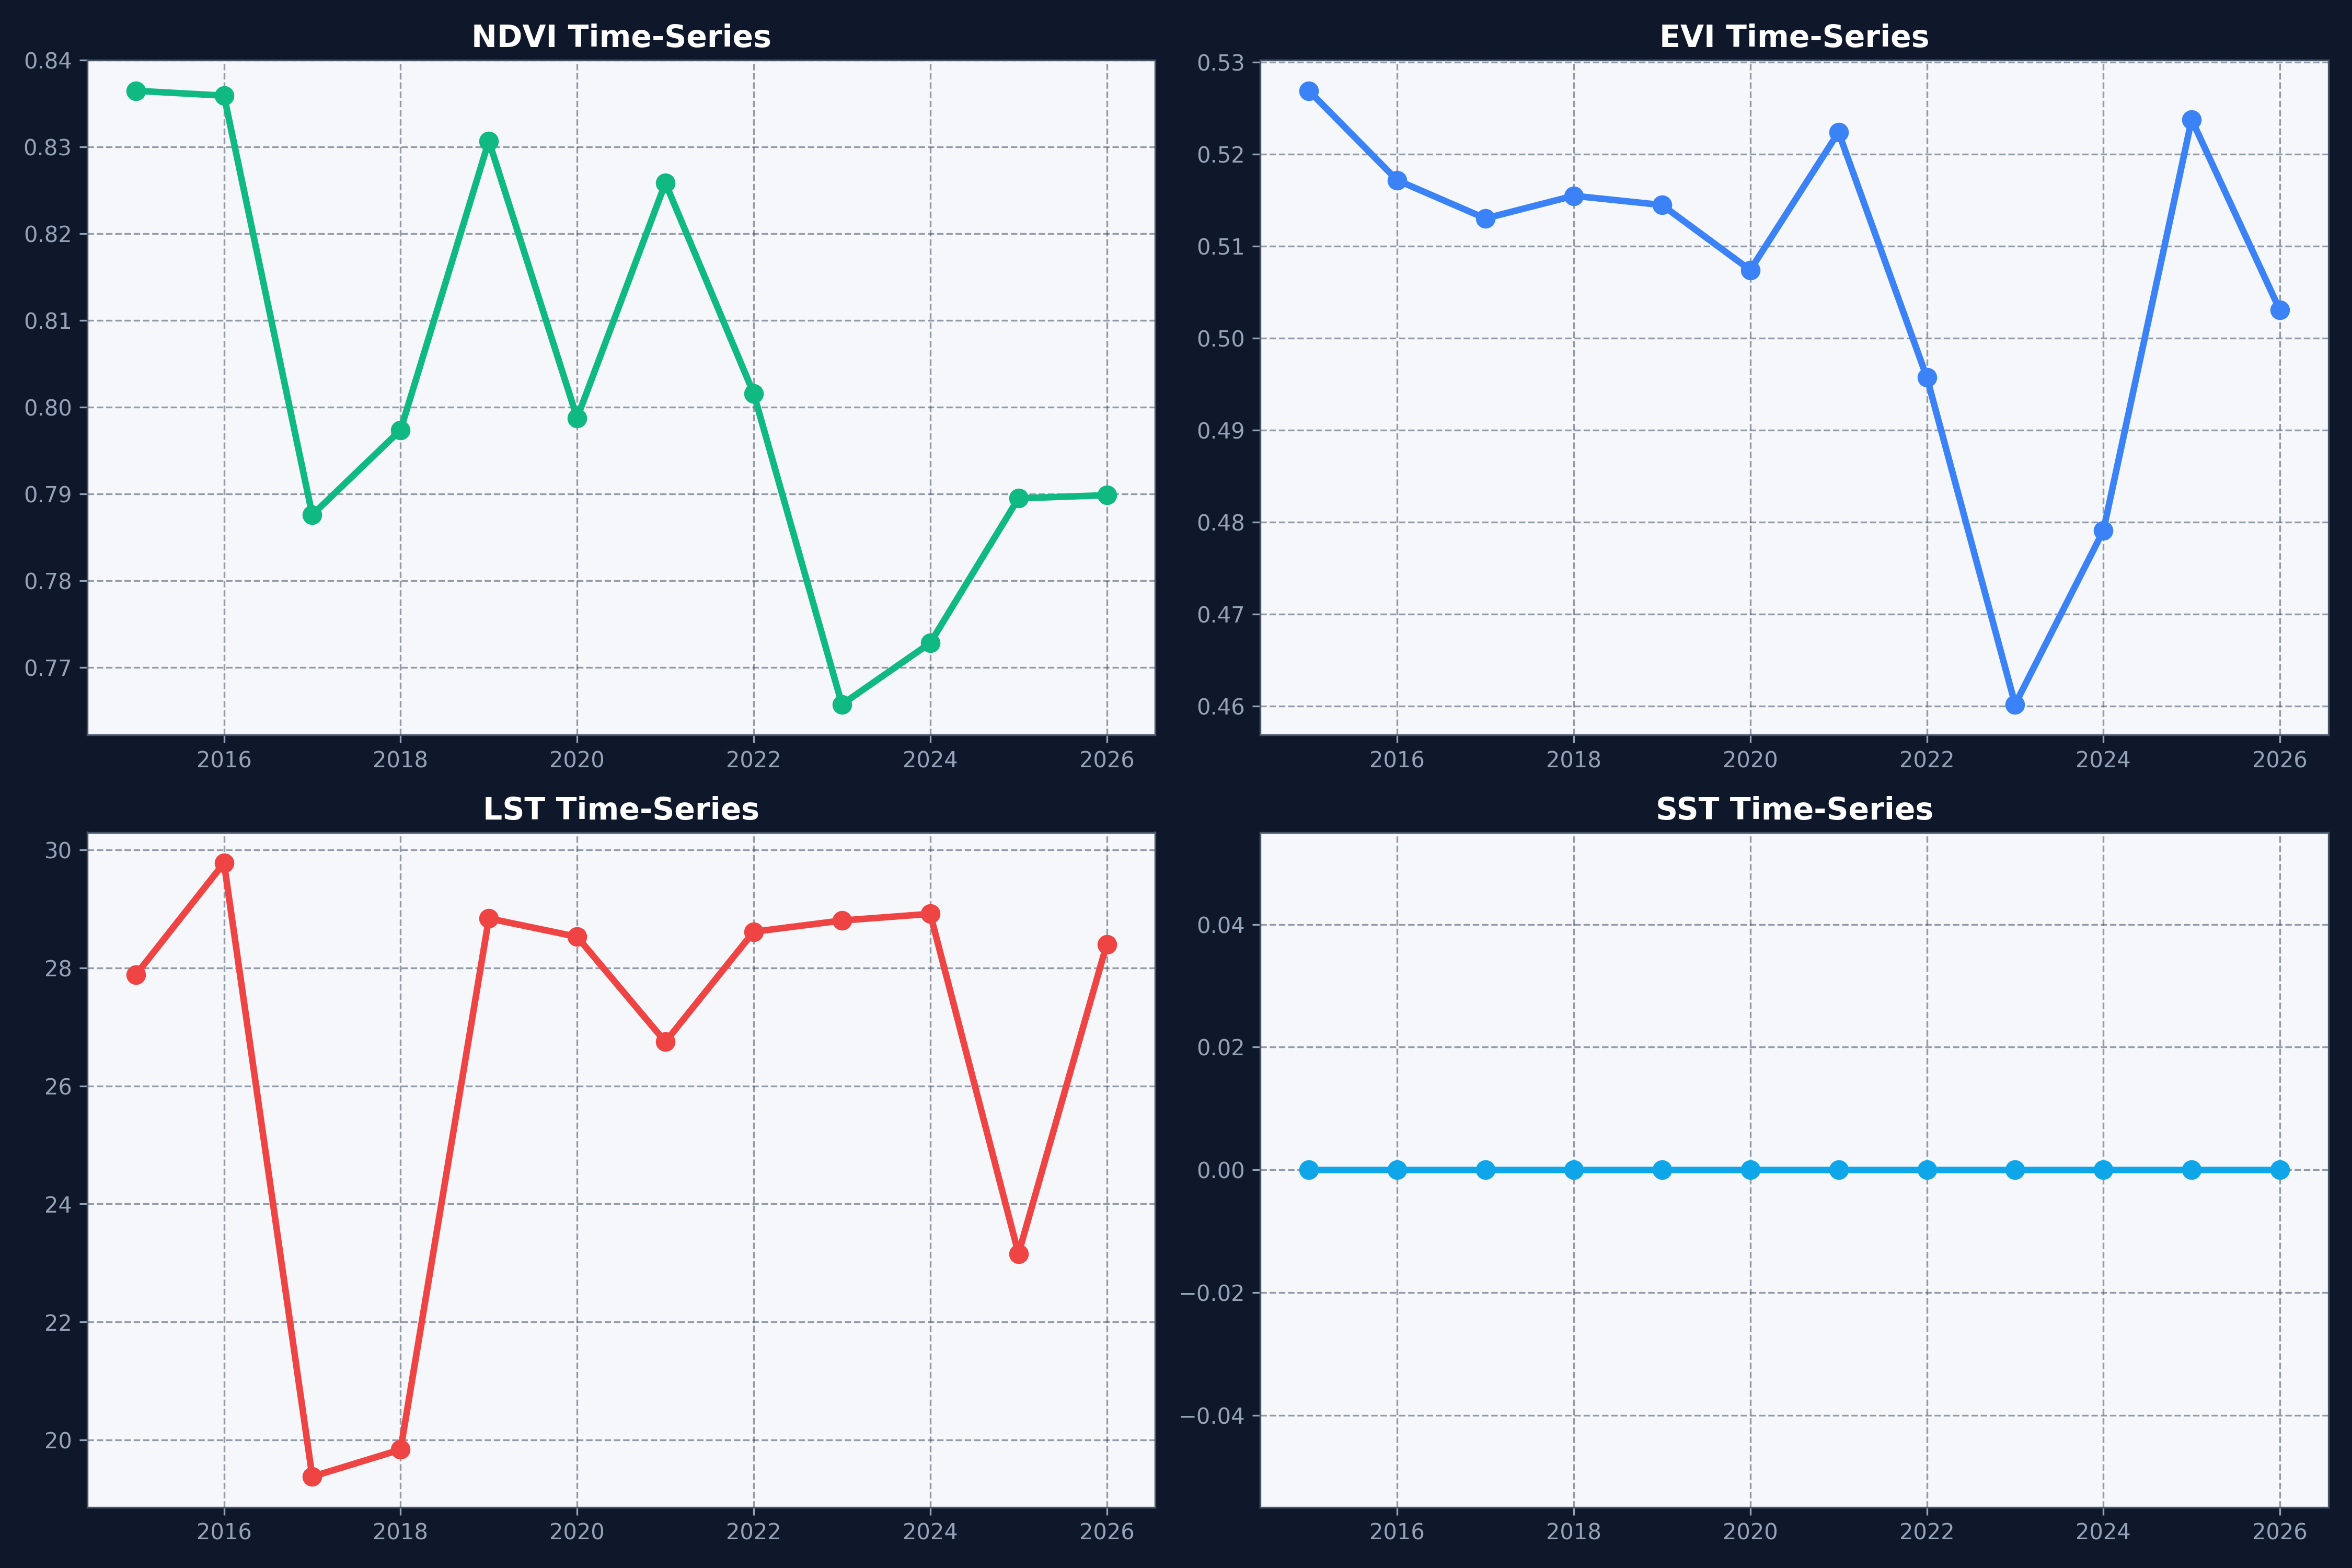

Map(center=[14.709732, 98.263013], controls=(WidgetControl(options=['position', 'transparent_bg'], position='t…


--- 🤖 Agent Response ---


Here's an analysis of the ecosystem for Taninthary Nature Reserve (lat=14.709732, lon=98.263013) from 2015 to 2026:

## 🌿 Environmental Intelligence Report for Taninthary Nature Reserve

### Introduction
An ecosystem health analysis was conducted for the Taninthary Nature Reserve, located at latitude 14.709732 and longitude 98.263013, covering the period from 2015 to 2026.

### Methodology
The assessment utilized key ecological indicators:
*   **NDVI (Normalized Difference Vegetation Index)**: Used to quantify vegetation greenness.
*   **EVI (Enhanced Vegetation Index)**: An optimized vegetation index with improved sensitivity in high biomass regions.
*   **LST (Land Surface Temperature)**: Measures the temperature of the land surface.

Data sources included Landsat 8 C2 (scaled) for land-based observations and MODIS datasets, which were automatically selected based on data availability for optimal analysis.

### Key Findings
The current assessment indicates a **STABLE** ecosystem for the Taninthary Nature Reserve during the 2015-2026 period.

| Metric | Baseline (2015) | Current (2026) | Trend (%) |
| :--- | :--- | :--- | :--- |
| **NDVI** | 0.836 | 0.790 | -5.6% |
| **EVI** | 0.527 | 0.503 | -4.5% |
| **LST** | 27.88°C | 28.40°C | +0.52°C |

**Key Insights:**
*   **Biomass Anomaly:** The Enhanced Vegetation Index (EVI) showed a minor shift of -4.5%. This could indicate minor seasonal or cyclical variations in vegetation biomass.
*   **Thermal Shift:** The land surface temperature (LST) experienced a slight increase of 0.52°C over the analyzed period.

### Recommendations for Future Conservation Efforts

Based on the findings, the following recommendations are suggested to support the continued health and stability of the Taninthary Nature Reserve:

1.  **Monitor Vegetation Trends Closely:** While the overall ecosystem is stable, the minor negative trends in NDVI and EVI warrant closer monitoring. Further investigation into the causes of these slight decreases, such as localized deforestation, agricultural encroachment, or climate-induced changes in vegetation productivity, would be beneficial.
2.  **Investigate Thermal Shifts:** The observed increase in Land Surface Temperature (LST) should be investigated to understand its potential impacts on the reserve's biodiversity and water resources. This could involve examining local climate data, changes in land cover, and potential influences from surrounding human activities.
3.  **Ground-Truthing and Field Surveys:** Complement the satellite-based monitoring with on-the-ground field surveys to validate the observed trends and gain a deeper understanding of the ecological processes at play. This can help identify specific areas of concern or success within the reserve.
4.  **Strengthen Protected Area Management:** Continue and, if possible, enhance existing conservation efforts, including anti-poaching measures, habitat protection, and community engagement initiatives, to mitigate potential threats.
5.  **Long-term Data Collection and Analysis:** Maintain consistent, long-term monitoring of these and other relevant environmental parameters to detect subtle changes and adapt conservation strategies proactively.
6.  **Consider Climate Change Adaptation:** Given the global climate change trends and the observed thermal shift, it would be prudent to incorporate climate change adaptation strategies into the reserve's management plan to enhance its resilience.

In [ ]:
import asyncio

# Use runner.run_async() — original called the tool directly, bypassing the agent
async def run_agent_task(query: str):
    print(f"\n🔍 Query: {query}\n")

    user_message = Content(
        role="user",
        parts=[Part(text=query)]
    )

    final_response = ""
    async for event in runner.run_async(
        user_id=USER_ID,
        session_id=SESSION_ID,
        new_message=user_message
    ):
        # Stream tool-call and model events
        if hasattr(event, 'content') and event.content:
            for part in event.content.parts:
                if hasattr(part, 'text') and part.text:
                    final_response += part.text

    print("\n--- 🤖 Agent Response ---")
    display(Markdown(final_response))

# Run — change the query or coordinates as needed
await run_agent_task(
    "Analyze the ecosystem for Taninthary Nature Reserve (lat=14.709732, lon=98.263013) from 2015 to 2026."
)